# Logistic Regression — crash severity classification

Single-model baseline alongside the TabNet / Stacking / MLP notebooks. Same
data, same seed, same split, same SMOTE rule, same Optuna config, same
metrics, same threshold sweep, same SHAP setup, same Light_conditions
sensitivity check. The only model-specific piece is a `StandardScaler -> LR`
pipeline (LR needs scaled inputs).

## Pipeline

1. Load `data/data_cleaned.csv`, define feature set, train / val / test split.
2. OrdinalEncoder on categoricals (+1 shift, parity with the other notebooks).
3. Optuna search on LR hyperparameters with 5-fold stratified CV. SMOTE on the
   training fold only.
4. Train final LR on full SMOTE-resampled training set.
5. Test set evaluation: accuracy, precision, recall, F1, AUC, confusion matrix.
6. Per-class threshold tuning with line plots.
7. SHAP analysis (KernelExplainer) and a Light_conditions sensitivity study.
8. Save model and metrics.

LR is CPU-only here. Color convention: Fatal = red, Serious = yellow, Slight = green.

## 1. Setup

In [2]:

import json
import logging
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
import optuna
import shap

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(message)s",
                    datefmt="%H:%M:%S")
log = logging.getLogger("lr")
logging.getLogger("shap").setLevel(logging.WARNING)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

SEED = 42
np.random.seed(SEED)

ROOT = Path.cwd()
DATA = ROOT / "data" / "data_cleaned.csv"
MODEL_DIR = ROOT / "models"
FIG_DIR = ROOT / "outputs" / "figures"
RESULTS = ROOT / "outputs" / "lr_metrics.json"
for p in (MODEL_DIR, FIG_DIR):
    p.mkdir(parents=True, exist_ok=True)

N_TRIALS = 50
N_FOLDS = 5
SHAP_BG = 100
SHAP_EVAL = 200

SEVERITY_ORDER = ["Slight Injury", "Serious Injury", "Fatal injury"]
SEVERITY_COLORS = {"Slight Injury": "#2ca02c", "Serious Injury": "#f1c40f", "Fatal injury": "#d62728"}
SEVERITY_PALETTE = [SEVERITY_COLORS[s] for s in SEVERITY_ORDER]
SEV_SHORT = ["Slight", "Serious", "Fatal"]


## 2. Helpers

`encode()` matches the encoder used in the Stacking notebook: OrdinalEncoder
with `-1` for unknowns, then a `+1` shift so unknowns occupy index 0. Trees
don't strictly need this for LR, but kept for parity. The LR itself sits
inside a `StandardScaler -> LR` pipeline so it always sees scaled inputs.

In [3]:

def define_features(df: pd.DataFrame):
    """Same feature contract as TabNet / Stacking / MLP."""
    drop_originals_with_ord = [
        "Age_band_of_driver", "Driving_experience",
        "Service_year_of_vehicle", "Educational_level",
    ]
    target_cols = ["Accident_severity", "Severity_code"]
    cat_cols = [c for c in df.select_dtypes(include="object").columns
                if c not in target_cols + drop_originals_with_ord]
    num_cols = [c for c in df.select_dtypes(include=["int64", "float64"]).columns
                if c not in target_cols]
    return cat_cols, num_cols


def encode(df, cat_cols, num_cols, encoder=None, fit=True):
    """OrdinalEncoder + unknown-shift; numeric features pass through unscaled
    (scaling happens inside the LR pipeline)."""
    cat = df[cat_cols].astype(str).values
    num = df[num_cols].astype(float).values

    if fit:
        encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        cat_enc = encoder.fit_transform(cat)
    else:
        cat_enc = encoder.transform(cat)

    cat_enc = cat_enc + 1
    X = np.concatenate([cat_enc, num], axis=1).astype(np.float32)
    return X, encoder


def metric_block(y_true, y_pred, y_proba, label=""):
    out = {
        "accuracy":         accuracy_score(y_true, y_pred),
        "precision_macro":  precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro":     recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro":         f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted":      f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc_ovr":      roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
    }
    print(f"=== {label} ===")
    for k, v in out.items():
        print(f"  {k:<18s} {v:.4f}")
    print("\n  classification report:")
    print(classification_report(y_true, y_pred, target_names=SEV_SHORT, zero_division=0))
    return out


def plot_confusion(cm, title, save_path=None):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(SEV_SHORT); ax.set_yticklabels(SEV_SHORT)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() * 0.5 else "black")
    plt.colorbar(im, ax=ax, fraction=0.04)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


## 3. Load data and split

Identical split to the other notebooks (same seed, same proportions, same
stratification) so all models are directly comparable.

In [4]:

df = pd.read_csv(DATA)
cat_cols, num_cols = define_features(df)
feature_names = cat_cols + num_cols

log.info(f"data shape: {df.shape}")
log.info(f"cat features ({len(cat_cols)}): {cat_cols}")
log.info(f"num features ({len(num_cols)}): {num_cols}")

y = df["Severity_code"].values
print(pd.Series(y).map(dict(enumerate(SEV_SHORT))).value_counts())


19:28:35 [INFO] data shape: (12316, 32)
19:28:35 [INFO] cat features (17): ['Day_of_week', 'Sex_of_driver', 'Vehicle_driver_relation', 'Type_of_vehicle', 'Owner_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Cause_of_accident', 'TimeOfDay']
19:28:35 [INFO] num features (9): ['Number_of_vehicles_involved', 'Number_of_casualties', 'Hour', 'RushHour', 'IsWeekend', 'Age_band_of_driver_ord', 'Driving_experience_ord', 'Service_year_of_vehicle_ord', 'Educational_level_ord']


Slight     10415
Serious     1743
Fatal        158
Name: count, dtype: int64


In [5]:

df_trainval, df_test = train_test_split(
    df, test_size=0.15, stratify=y, random_state=SEED)
df_train, df_val = train_test_split(
    df_trainval, test_size=0.1765,
    stratify=df_trainval["Severity_code"].values, random_state=SEED)

log.info(f"train={len(df_train)}  val={len(df_val)}  test={len(df_test)}")

X_train, encoder = encode(df_train, cat_cols, num_cols, fit=True)
X_val, _ = encode(df_val, cat_cols, num_cols, encoder, fit=False)
X_test, _ = encode(df_test, cat_cols, num_cols, encoder, fit=False)
y_train = df_train["Severity_code"].values
y_val = df_val["Severity_code"].values
y_test = df_test["Severity_code"].values
log.info(f"feature dim: {X_train.shape[1]}")


19:28:35 [INFO] train=8620  val=1848  test=1848
19:28:35 [INFO] feature dim: 26


## 4. Optuna hyperparameter search

Tunes LR via penalty (l1 / l2 / elasticnet), inverse regularization strength C,
and l1_ratio (only used when penalty=elasticnet; gated via `suggest_categorical`
+ conditional `suggest_float`). solver=saga so all three penalties are supported.

Objective: macro-F1 — same justification as the other notebooks (Fatal class is
rare).

In [6]:

def build_lr(C, penalty, l1_ratio):
    """LR wrapped in StandardScaler. l1_ratio is ignored for non-elasticnet."""
    return Pipeline([
        ("sc", StandardScaler()),
        ("lr", LogisticRegression(
            solver="saga", penalty=penalty,
            C=C, l1_ratio=l1_ratio if penalty == "elasticnet" else None,
            max_iter=3000, random_state=SEED, n_jobs=-1,
        )),
    ])


class OptunaProgress:
    def __init__(self, total): self.total = total; self.t0 = time.time()

    def __call__(self, study, trial):
        elapsed = time.time() - self.t0
        avg = elapsed / (trial.number + 1)
        eta = avg * (self.total - trial.number - 1)
        log.info(f"trial {trial.number + 1:>2d}/{self.total} | "
                 f"value={trial.value:.4f} | best={study.best_value:.4f} | "
                 f"elapsed={elapsed:>6.1f}s | ETA={eta:>6.1f}s")


In [7]:

def objective(trial):
    penalty = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet"])
    C = trial.suggest_float("C", 1e-3, 10.0, log=True)
    l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0) if penalty == "elasticnet" else 0.0

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_scores = []
    for tr_idx, va_idx in skf.split(X_train, y_train):
        X_tr, X_va = X_train[tr_idx], X_train[va_idx]
        y_tr, y_va = y_train[tr_idx], y_train[va_idx]

        sm = SMOTE(random_state=SEED, k_neighbors=5)
        X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

        model = build_lr(C=C, penalty=penalty, l1_ratio=l1_ratio)
        model.fit(X_tr_sm, y_tr_sm)
        preds = model.predict(X_va)
        fold_scores.append(f1_score(y_va, preds, average="macro"))
    return float(np.mean(fold_scores))


In [8]:

log.info(f"Starting Optuna search: {N_TRIALS} trials, {N_FOLDS}-fold CV")
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED, multivariate=True),
)
t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, callbacks=[OptunaProgress(N_TRIALS)])
log.info(f"Optuna done in {time.time() - t0:.1f}s")
log.info(f"best macro-F1: {study.best_value:.4f}")
log.info(f"best params: {study.best_params}")

best_params = dict(study.best_params)


19:28:35 [INFO] Starting Optuna search: 50 trials, 5-fold CV
19:28:36 [INFO] trial  1/50 | value=0.2930 | best=0.2930 | elapsed=   0.6s | ETA=  27.6s
19:28:40 [INFO] trial  2/50 | value=0.2928 | best=0.2930 | elapsed=   5.2s | ETA= 123.7s
19:28:47 [INFO] trial  3/50 | value=0.2929 | best=0.2930 | elapsed=  11.6s | ETA= 181.3s
19:28:47 [INFO] trial  4/50 | value=0.2848 | best=0.2930 | elapsed=  12.1s | ETA= 139.4s
19:28:48 [INFO] trial  5/50 | value=0.2926 | best=0.2930 | elapsed=  12.6s | ETA= 113.4s
19:28:48 [INFO] trial  6/50 | value=0.2920 | best=0.2930 | elapsed=  13.2s | ETA=  96.8s
19:28:49 [INFO] trial  7/50 | value=0.2930 | best=0.2930 | elapsed=  13.7s | ETA=  84.2s
19:28:49 [INFO] trial  8/50 | value=0.2914 | best=0.2930 | elapsed=  14.3s | ETA=  75.1s
19:28:50 [INFO] trial  9/50 | value=0.2927 | best=0.2930 | elapsed=  14.8s | ETA=  67.3s
19:28:50 [INFO] trial 10/50 | value=0.2915 | best=0.2930 | elapsed=  15.3s | ETA=  61.0s
[W 2026-05-20 19:28:50,893] The parameter `l1_rat

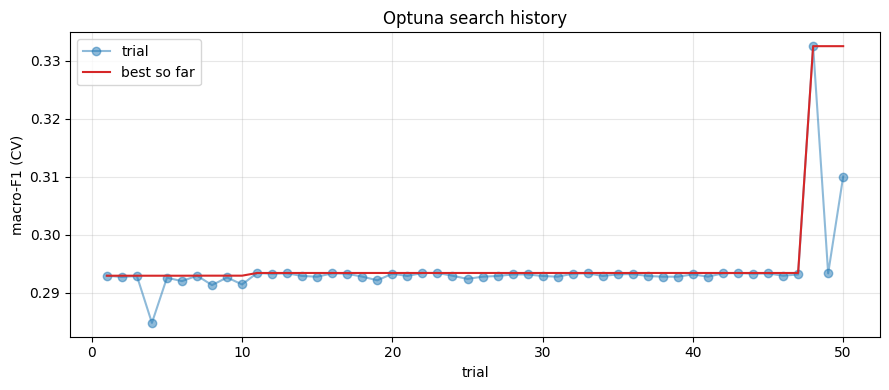

In [9]:

trial_vals = [t.value for t in study.trials if t.value is not None]
running_best = np.maximum.accumulate(trial_vals)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(trial_vals) + 1), trial_vals, "o-", alpha=0.5, label="trial")
ax.plot(range(1, len(running_best) + 1), running_best, "-", color="#d62728", label="best so far")
ax.set_xlabel("trial"); ax.set_ylabel("macro-F1 (CV)")
ax.set_title("Optuna search history")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "lr_optuna_history.png", dpi=150)
plt.show()


## 5. Train final Logistic Regression

In [10]:

log.info("SMOTE on full training set ...")
sm = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
log.info(f"SMOTE: {len(y_train)} -> {len(y_train_sm)}")
log.info(f"class counts after SMOTE: {pd.Series(y_train_sm).value_counts().sort_index().tolist()}")

bp = best_params
final_model = build_lr(
    C=bp["C"],
    penalty=bp["penalty"],
    l1_ratio=bp.get("l1_ratio", 0.0),
)
t0 = time.time()
final_model.fit(X_train_sm, y_train_sm)
log.info(f"final fit in {time.time() - t0:.1f}s")


19:30:24 [INFO] SMOTE on full training set ...
19:30:24 [INFO] SMOTE: 8620 -> 21867
19:30:24 [INFO] class counts after SMOTE: [7289, 7289, 7289]
19:30:24 [INFO] final fit in 0.1s


In [11]:

# Quick validation-set sanity check before going to the held-out test set.
val_pred = final_model.predict(X_val)
val_proba = final_model.predict_proba(X_val)
_ = metric_block(y_val, val_pred, val_proba, label="Validation set")


=== Validation set ===
  accuracy           0.3496
  precision_macro    0.3532
  recall_macro       0.4665
  f1_macro           0.2548
  f1_weighted        0.4313
  roc_auc_ovr        0.6174

  classification report:
              precision    recall  f1-score   support

      Slight       0.88      0.32      0.47      1563
     Serious       0.15      0.49      0.23       261
       Fatal       0.03      0.58      0.06        24

    accuracy                           0.35      1848
   macro avg       0.35      0.47      0.25      1848
weighted avg       0.76      0.35      0.43      1848



## 6. Test set evaluation

=== Test set (argmax) ===
  accuracy           0.3539
  precision_macro    0.3516
  recall_macro       0.4051
  f1_macro           0.2525
  f1_weighted        0.4372
  roc_auc_ovr        0.5911

  classification report:
              precision    recall  f1-score   support

      Slight       0.88      0.33      0.48      1563
     Serious       0.16      0.51      0.24       261
       Fatal       0.02      0.38      0.04        24

    accuracy                           0.35      1848
   macro avg       0.35      0.41      0.25      1848
weighted avg       0.76      0.35      0.44      1848



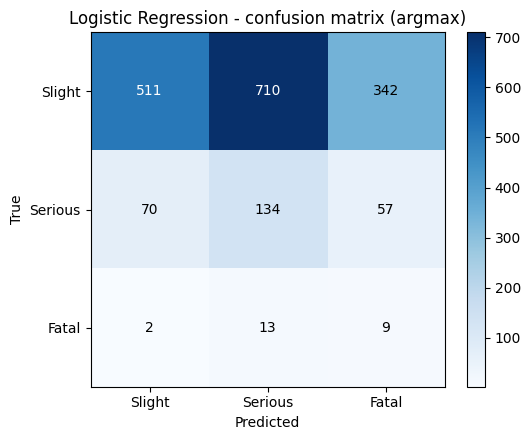

In [12]:

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

test_metrics = metric_block(y_test, y_pred, y_proba, label="Test set (argmax)")
cm = confusion_matrix(y_test, y_pred)
plot_confusion(cm, "Logistic Regression - confusion matrix (argmax)",
               save_path=FIG_DIR / "lr_confusion_argmax.png")


## 7. Per-class threshold tuning

Same approach as the other notebooks: sweep one-vs-rest thresholds and pick
the per-class F1 maximum.

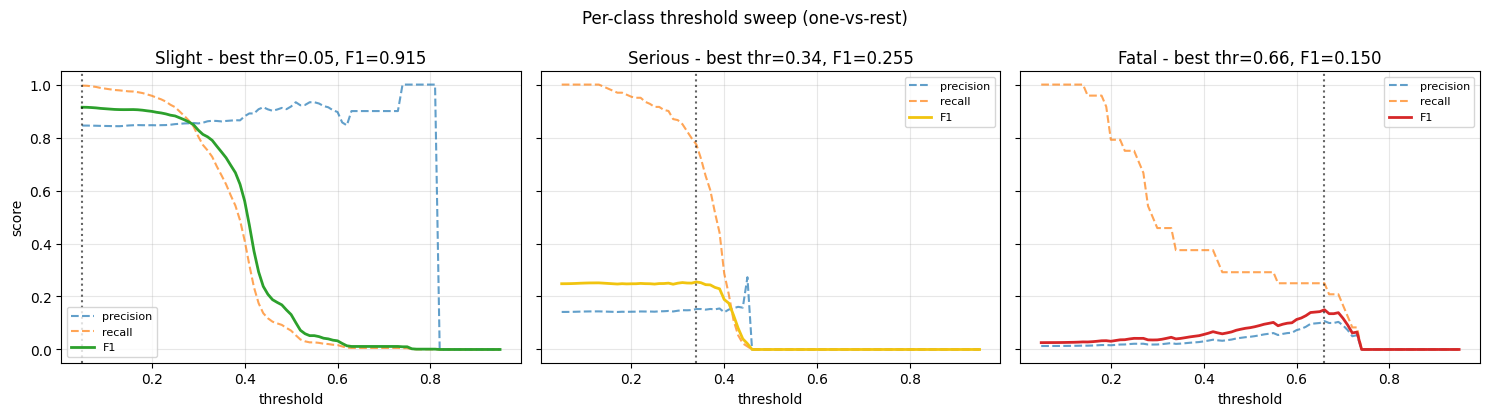

Best per-class thresholds: {'Slight': 0.05, 'Serious': 0.33999999999999997, 'Fatal': 0.6599999999999999}


In [13]:

thresholds = np.linspace(0.05, 0.95, 91)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
best_thr = {}

for k, (name, color) in enumerate(zip(SEV_SHORT, SEVERITY_PALETTE)):
    f1s, pres, recs = [], [], []
    y_bin = (y_test == k).astype(int)
    for thr in thresholds:
        p_bin = (y_proba[:, k] >= thr).astype(int)
        f1s.append(f1_score(y_bin, p_bin, zero_division=0))
        pres.append(precision_score(y_bin, p_bin, zero_division=0))
        recs.append(recall_score(y_bin, p_bin, zero_division=0))

    f1s = np.array(f1s); pres = np.array(pres); recs = np.array(recs)
    best_idx = int(np.argmax(f1s))
    best_thr[name] = float(thresholds[best_idx])

    ax = axes[k]
    ax.plot(thresholds, pres, label="precision", color="#1f77b4", linestyle="--", alpha=0.7)
    ax.plot(thresholds, recs, label="recall",    color="#ff7f0e", linestyle="--", alpha=0.7)
    ax.plot(thresholds, f1s,  label="F1",        color=color, linewidth=2)
    ax.axvline(thresholds[best_idx], color="black", linestyle=":", alpha=0.6)
    ax.set_title(f"{name} - best thr={thresholds[best_idx]:.2f}, F1={f1s[best_idx]:.3f}")
    ax.set_xlabel("threshold")
    if k == 0: ax.set_ylabel("score")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Per-class threshold sweep (one-vs-rest)")
plt.tight_layout()
plt.savefig(FIG_DIR / "lr_threshold_sweep.png", dpi=150)
plt.show()
print("Best per-class thresholds:", best_thr)


=== Test set (threshold-tuned) ===
  accuracy           0.5173
  precision_macro    0.3818
  recall_macro       0.4391
  f1_macro           0.3511
  f1_weighted        0.5862
  roc_auc_ovr        0.5911

  classification report:
              precision    recall  f1-score   support

      Slight       0.87      0.52      0.65      1563
     Serious       0.17      0.55      0.26       261
       Fatal       0.11      0.25      0.15        24

    accuracy                           0.52      1848
   macro avg       0.38      0.44      0.35      1848
weighted avg       0.76      0.52      0.59      1848



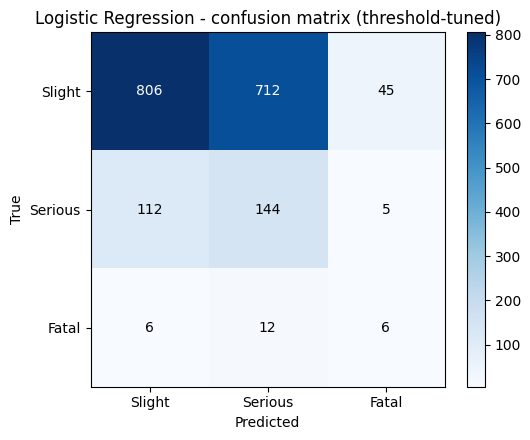

In [14]:

def predict_with_thresholds(proba, thr_map):
    thr_arr = np.array([thr_map[n] for n in SEV_SHORT])
    above = proba >= thr_arr
    out = np.full(len(proba), -1, dtype=int)
    for i in range(len(proba)):
        if above[i].any():
            cand = np.where(above[i])[0]
            out[i] = cand[np.argmax(proba[i, cand])]
        else:
            out[i] = int(np.argmax(proba[i]))
    return out


y_pred_tuned = predict_with_thresholds(y_proba, best_thr)
tuned_metrics = metric_block(y_test, y_pred_tuned, y_proba,
                             label="Test set (threshold-tuned)")
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plot_confusion(cm_tuned, "Logistic Regression - confusion matrix (threshold-tuned)",
               save_path=FIG_DIR / "lr_confusion_tuned.png")


## 8. Save model and metrics

In [15]:

save_path = MODEL_DIR / "lr_best.joblib"
joblib.dump({
    "model": final_model,
    "encoder": encoder,
    "cat_cols": cat_cols, "num_cols": num_cols,
    "feature_names": feature_names,
    "best_params": best_params,
    "best_thresholds": best_thr,
}, save_path)

results = {
    "best_params": best_params,
    "best_thresholds": best_thr,
    "test_argmax": test_metrics,
    "test_threshold_tuned": tuned_metrics,
    "confusion_argmax": cm.tolist(),
    "confusion_tuned": cm_tuned.tolist(),
    "n_train": int(len(y_train)), "n_val": int(len(y_val)), "n_test": int(len(y_test)),
}
RESULTS.write_text(json.dumps(results, indent=2))
log.info(f"Saved model to {save_path}")
log.info(f"Wrote {RESULTS}")


19:30:25 [INFO] Saved model to /home/thsondev/Projects/crash-severity-tabnet-stacking/models/lr_best.joblib
19:30:25 [INFO] Wrote /home/thsondev/Projects/crash-severity-tabnet-stacking/outputs/lr_metrics.json


## 8.5 Coefficient table & equation export

Loads the saved `models/lr_best.joblib` and writes out the multinomial LR
weights in two views:

- **Standardized form** (`coef_std`): coefficient on the z-scored input.
  Magnitudes are directly comparable across features — this is the right
  view for importance ranking.
- **Raw form** (`coef_raw = coef_std / std`, with the intercept absorbed):
  plug raw `x` values straight in. Magnitudes are *not* comparable.

Prints both the full per-class equation (skipping exact zeros) and a
shortened top-5 form suitable for the paper.


In [ ]:
# Reload the persisted pipeline so this cell is independent of in-memory state.
artifact = joblib.load(MODEL_DIR / "lr_best.joblib")
pipe       = artifact["model"]
feat_names = artifact["feature_names"]
scaler = pipe.named_steps["sc"]
clf    = pipe.named_steps["lr"]

mu, sigma = scaler.mean_, scaler.scale_
coef_std    = clf.coef_                       # (3, F) on z-scored features
intercept_z = clf.intercept_                  # (3,)
coef_raw    = coef_std / sigma                # weight when plugging raw x
intercept_raw = intercept_z - (coef_std * (mu / sigma)).sum(axis=1)

# Long-form coefficient table for the paper.
rows = []
for k, cls_name in enumerate(SEV_SHORT):
    for j, feat in enumerate(feat_names):
        rows.append({
            "class": cls_name,
            "feature": feat,
            "coef_std": float(coef_std[k, j]),
            "coef_raw": float(coef_raw[k, j]),
            "abs_coef_std": float(abs(coef_std[k, j])),
        })
coef_df = pd.DataFrame(rows)
coef_csv = ROOT / "outputs" / "lr_coefficients.csv"
coef_df.to_csv(coef_csv, index=False)
log.info(f"Wrote {coef_csv}")

n_zero = int((coef_std == 0).sum())
log.info(f"Penalty={clf.penalty} -> {n_zero} of {coef_std.size} coefficients are exactly zero")

# Global importance: mean |coef_std| across the three classes.
global_imp = (coef_df.groupby("feature")["abs_coef_std"]
              .mean().sort_values(ascending=False))
print("Top-10 features by mean |coef_std| across classes:")
print(global_imp.head(10).round(3).to_string())


def _format_equation(k: int, top_n: int | None = None) -> str:
    """Return 'logit(class) = b + w1*z[feat1] + ...' as a string.
    Zero coefficients are always skipped. top_n caps the visible terms;
    None keeps all non-zero terms."""
    w = coef_std[k]
    nz = np.flatnonzero(w)
    order = nz[np.argsort(-np.abs(w[nz]))]
    truncated = top_n is not None and len(order) > top_n
    if top_n is not None:
        order = order[:top_n]
    parts = [f"logit({SEV_SHORT[k]}) = {intercept_z[k]:+.3f}"]
    for j in order:
        parts.append(f"{w[j]:+.3f}*z[{feat_names[j]}]")
    if len(parts) == 1:
        parts.append("(all coefficients zero)")
    return " ".join(parts) + (" + ..." if truncated else "")


nz_per_class = (coef_std != 0).sum(axis=1)
lines = []
lines.append("=" * 80)
lines.append("FULL equations (standardized z-features; zero terms suppressed)")
lines.append("non-zero terms per class: " + ", ".join(
    f"{SEV_SHORT[k]}={int(nz_per_class[k])}" for k in range(3)))
lines.append("=" * 80)
for k in range(3):
    lines.append(_format_equation(k, top_n=None))
    lines.append("")

lines.append("=" * 80)
lines.append("SHORT equations - up to top 5 non-zero features per class")
lines.append("=" * 80)
for k in range(3):
    lines.append(_format_equation(k, top_n=5))
    lines.append("")

eq_text = "\n".join(lines)
print(eq_text)

eq_path = ROOT / "outputs" / "lr_equation.txt"
eq_path.write_text(eq_text)
log.info(f"Wrote {eq_path}")


## 9. SHAP interpretation

KernelExplainer on the LR pipeline's `predict_proba`. Background and eval sizes
match the other notebooks for cross-model parity.

In [16]:

rng = np.random.default_rng(SEED)
bg_idx = rng.choice(len(X_train_sm), size=min(SHAP_BG, len(X_train_sm)), replace=False)
background = X_train_sm[bg_idx]

eval_idx = rng.choice(len(X_test), size=min(SHAP_EVAL, len(X_test)), replace=False)
X_shap = X_test[eval_idx]

log.info(f"SHAP: background={len(background)}, eval={len(X_shap)}")
explainer = shap.KernelExplainer(final_model.predict_proba, background)
t0 = time.time()
shap_values = explainer.shap_values(X_shap, nsamples=100)
log.info(f"SHAP done in {time.time() - t0:.1f}s; shape={np.array(shap_values).shape}")


19:30:25 [INFO] SHAP: background=100, eval=200
100%|██████████| 200/200 [00:01<00:00, 170.22it/s]
19:30:26 [INFO] SHAP done in 1.2s; shape=(200, 26, 3)


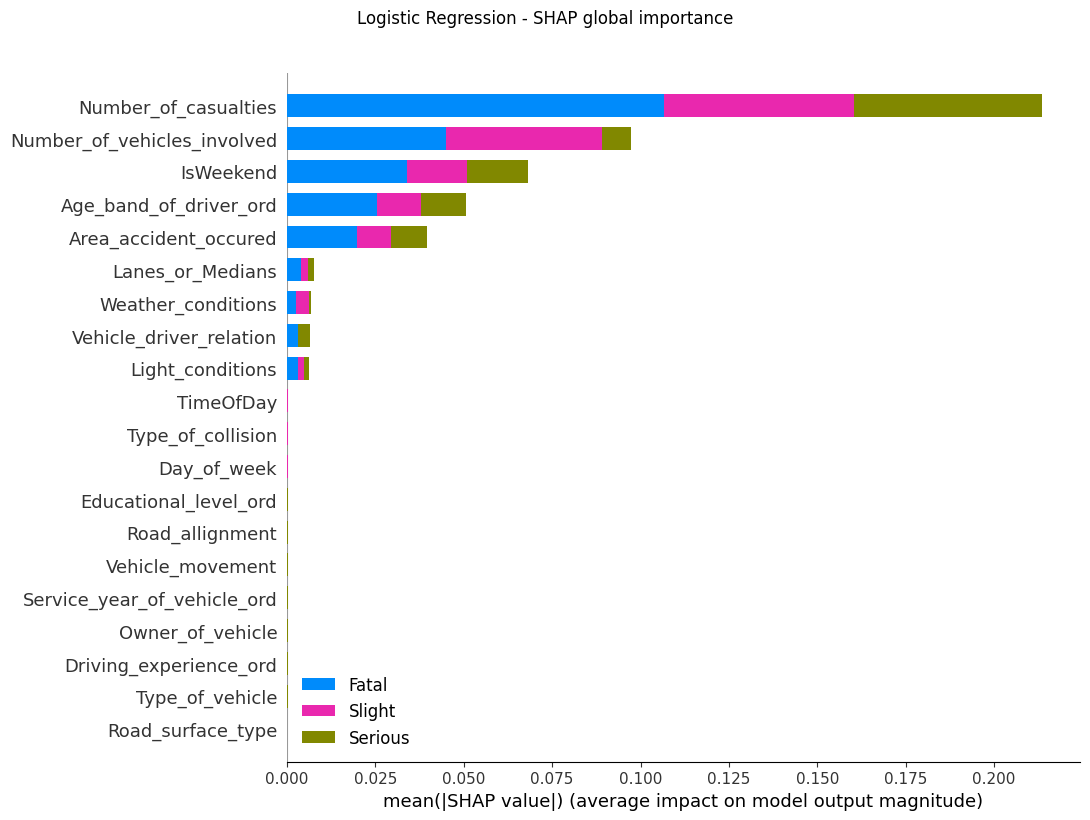

In [17]:

# Convert SHAP output to a per-class list of (N, F) arrays, then global bar plot.
if isinstance(shap_values, list):
    shap_per_class = shap_values
else:
    shap_per_class = [shap_values[:, :, k] for k in range(3)]

shap.summary_plot(shap_per_class, X_shap, feature_names=feature_names,
                  plot_type="bar", class_names=SEV_SHORT, show=False, plot_size=(11, 8))
fig = plt.gcf(); fig.suptitle("Logistic Regression - SHAP global importance", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "lr_shap_summary_bar.png", dpi=150, bbox_inches="tight")
plt.show()


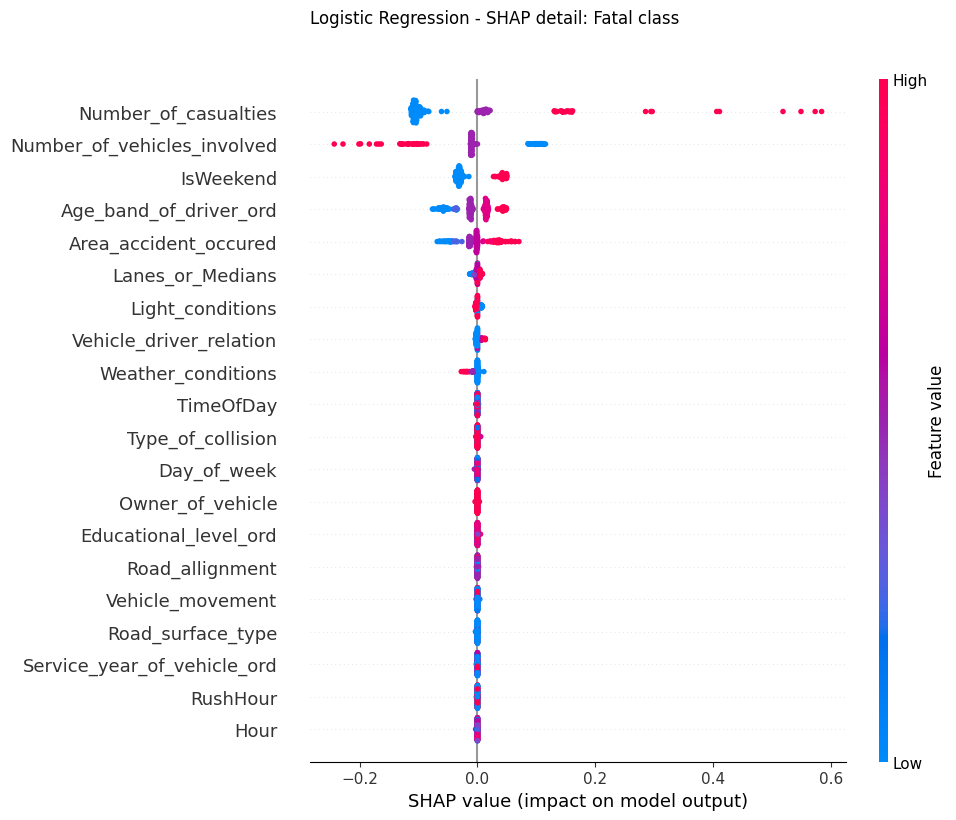

In [18]:

fatal_idx = SEV_SHORT.index("Fatal")
shap.summary_plot(shap_per_class[fatal_idx], X_shap, feature_names=feature_names,
                  plot_type="dot", show=False, plot_size=(10, 8))
fig = plt.gcf(); fig.suptitle("Logistic Regression - SHAP detail: Fatal class", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "lr_shap_dot_fatal.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Post-hoc / sensitivity analysis

Same intervention as the other notebooks: set `Light_conditions` to 'Daylight'
across the test set and compare mean predicted probabilities.

Mean predicted probability shift after setting Light_conditions='Daylight':
  Slight   original=0.3689  intervened=0.3701  delta=+0.0012
  Serious  original=0.3556  intervened=0.3568  delta=+0.0012
  Fatal    original=0.2755  intervened=0.2730  delta=-0.0024


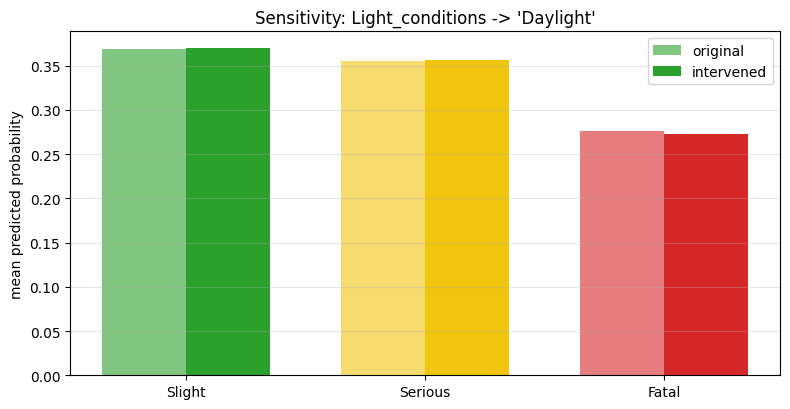

In [19]:

target_feature = "Light_conditions"
intervene_value = "Daylight"

if intervene_value not in df["Light_conditions"].unique():
    intervene_value = df["Light_conditions"].mode().iloc[0]
    log.info(f"'Daylight' not in data; intervening with '{intervene_value}' instead")

df_test_int = df_test.copy()
df_test_int[target_feature] = intervene_value
X_test_int, _ = encode(df_test_int, cat_cols, num_cols, encoder, fit=False)
proba_int = final_model.predict_proba(X_test_int)

orig_mean = y_proba.mean(axis=0)
intv_mean = proba_int.mean(axis=0)
delta = intv_mean - orig_mean

print(f"Mean predicted probability shift after setting {target_feature}='{intervene_value}':")
for name, o, i, d in zip(SEV_SHORT, orig_mean, intv_mean, delta):
    print(f"  {name:<8s} original={o:.4f}  intervened={i:.4f}  delta={d:+.4f}")

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(3); w = 0.35
ax.bar(x - w/2, orig_mean, width=w, color=SEVERITY_PALETTE, label="original", alpha=0.6)
ax.bar(x + w/2, intv_mean, width=w, color=SEVERITY_PALETTE, label="intervened", alpha=1.0)
ax.set_xticks(x); ax.set_xticklabels(SEV_SHORT)
ax.set_ylabel("mean predicted probability")
ax.set_title(f"Sensitivity: {target_feature} -> '{intervene_value}'")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "lr_sensitivity_light.png", dpi=150)
plt.show()


## 11. Summary

- Best Optuna macro-F1 (CV): see log above.
- Argmax test metrics + threshold-tuned test metrics reported.
- Saved artefacts: `models/lr_best.joblib`, `outputs/lr_metrics.json`, and
  figures under `outputs/figures/lr_*.png`.

Run alongside `tabnet.ipynb`, `stacking-ensemble.ipynb`, and `mlp.ipynb` for
direct comparison - all four notebooks share the same train/val/test split
(same seed, same proportions) and the same feature contract.